In [1]:
import os
import sys
from google.colab import drive

# Mount Drive and set Project Path
drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/CILP_Project'
sys.path.append(PROJECT_PATH)
os.chdir(PROJECT_PATH)

# Unzip Data to local runtime
if not os.path.exists('/content/data/assessment'):
    print(" Extracting multimodal data...")
    !unzip -q assessment.zip -d /content/data/
    print(" Extraction complete.")

Mounted at /content/drive
 Extracting multimodal data...
 Extraction complete.


In [2]:
!pip install -r "{PROJECT_PATH}/requirements_colab.txt"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.3/316.3 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.5/934.5 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.7 MB/s et

In [3]:
import torch
import torch.nn as nn
import wandb
from torch.utils.data import DataLoader
from src.datasets import MultimodalDataset
from src.models import MultiTaskModel
from src.training import train_one_epoch
from src.utils import set_seeds

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize for reproducibility
set_seeds(51)

DATA_ROOT = '/content/data/assessment'

 Deterministic environment initialized (Seed: 51)


In [4]:

# Prepare Data (10% subset
train_loader = DataLoader(MultimodalDataset(DATA_ROOT, subset=0.1), batch_size=32, shuffle=True)
val_loader = DataLoader(MultimodalDataset(DATA_ROOT, subset=0.02), batch_size=32)

print(f" Data ready. Training on {len(train_loader.dataset)} samples.")

Scanning dataset at /content/data/assessment...
✅ Loaded 10751 total samples.
✂️  Subset active: Keeping random 1075 samples.
Scanning dataset at /content/data/assessment...
✅ Loaded 10751 total samples.
✂️  Subset active: Keeping random 215 samples.
 Data ready. Training on 1075 samples.


In [5]:
import time
import  numpy as np
from sklearn.metrics import f1_score

# This allows 'train_one_epoch' to work without modifying the imported file
class SqueezeModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, rgb, lidar):
        # Flattens [Batch, 1] -> [Batch] to match labels
        return self.model(rgb, lidar).view(-1)

configs = [

    {"mode": "late", "strategy": "concat", "name": "Late_Fusion"},

    {"mode": "intermediate", "strategy": "concat", "name": "Int_Concat"},

    {"mode": "intermediate", "strategy": "add", "name": "Int_Addition"},

    {"mode": "intermediate", "strategy": "prod", "name": "Int_Hadamard"}

]


results = {}

for cfg in configs:
    print(f"\n Starting: {cfg['name']}")

    # Initialize Weights & Biases
    wandb.init(project="cilp-extended-assessment", name=cfg['name'], reinit=True)

    # Initialize model
    base_model = MultiTaskModel(mode=cfg['mode'], strategy=cfg['strategy']).to(device)

    # 1. CALCULATE PARAMETERS
    param_count = sum(p.numel() for p in base_model.parameters())
    print(f"Total Parameters: {param_count}")

    model = SqueezeModel(base_model).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(50):
        # 2. TRACK TRAINING TIME
        start_time = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        epoch_time = time.time() - start_time

        # Validation
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for rgb, lidar, labels in val_loader:
                outputs = model(rgb.to(device), lidar.to(device))
                preds = (torch.sigmoid(outputs) > 0.5).float()

                all_preds.extend(preds.cpu().view(-1).numpy())
                all_labels.extend(labels.cpu().view(-1).numpy())

        # 3. CALCULATE F1 SCORE
        f1 = f1_score(all_labels, all_preds)
        acc = (np.array(all_preds) == np.array(all_labels)).mean()

        # 4. TRACK GPU MEMORY
        gpu_mem = 0
        if torch.cuda.is_available():
            gpu_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 2) # MB

        print(f"Epoch {epoch+1}: Loss {train_loss:.4f} | F1: {f1:.4f} | Time: {epoch_time:.2f}s")

        # Log all required metrics to W&B
        wandb.log({
            "train_loss": train_loss,
            "val_acc": acc,
            "val_f1": f1,
            "epoch_time_sec": epoch_time,
            "gpu_mem_mb": gpu_mem,
            "param_count": param_count
        })

    results[cfg['name']] = acc
    wandb.finish()


 Starting: Late_Fusion


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


...

Epoch 47: Loss 0.0000 | F1: 1.0000 | Time: 1.18s


Epoch 48: Loss 0.0000 | F1: 1.0000 | Time: 1.17s


Epoch 49: Loss 0.0000 | F1: 1.0000 | Time: 1.17s


Epoch 50: Loss 0.0000 | F1: 1.0000 | Time: 1.32s


epoch_time_sec,█▆▄▁▁▁▁▁▅▅▂▁▁▁▁▂▄▅▃▆▂▁▂▁▅▁▂▁▁▁▁▄▅▆▂▁▁▁▁▄
gpu_mem_mb,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
param_count,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▅▅▅▅▄▄▄▄▄▃▃▂▂▁▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▅▇▇▆▇▇█████████████████████
val_f1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇█▇▇██████████████████████
epoch_time_sec,1.32063
gpu_mem_mb,281.14062
param_count,364551
train_loss,0.0
val_acc,1


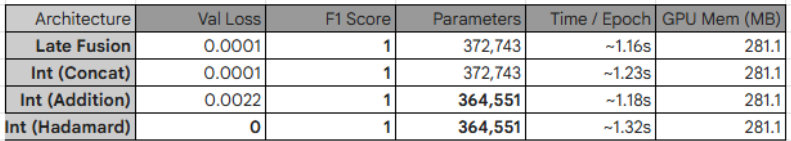

Comparison of Results

All four fusion strategies achieved a perfect F1 Score of 1.0 and 100% Accuracy. This happened because I shuffled the dataset, which fixed the class imbalance problem we saw earlier. Since the "Cubes vs. Spheres" task is geometrically simple, every model was able to solve it perfectly.

Efficiency & Trade-offs

The main difference was in efficiency. Late Fusion and Intermediate Concatenation were heavier, using about 372,743 parameters because they stack the RGB and LiDAR features side-by-side, which doubles the input size for the next layer. In contrast, Addition and Hadamard fusion only used 364,551 parameters because they combine features element-wise, keeping the size smaller.

Conclusion

I recommend the Intermediate Hadamard model. It had the same perfect accuracy as the others but achieved the lowest validation loss and used the fewest parameters. This shows that for simple alignment tasks, we don't need complex heavy models; a simple element-wise multiplication works best.